In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns   
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


In [39]:
df = pd.read_csv('SalaryData.csv')
df.head()
df.dropna(inplace=True)

In [3]:
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [12]:
# to keep only three columns
df1 = df[['Age','Years of Experience',
 'Salary']]
# to get all column names in the dataset written in a list
# df.columns.tolist()

In [15]:
df1.head()

,Age,Years of Experience,Salary
0,32.0,5.0,90000.0
1,28.0,3.0,65000.0
2,45.0,15.0,150000.0
3,36.0,7.0,60000.0
4,52.0,20.0,200000.0


In [40]:
df1.dropna(inplace=True)

Train Test Split

In [13]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [36]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df1.drop('Salary', axis=1),
                                                    df1['Salary'],
                                                    test_size=0.3,
                                                    random_state=0)

X_train.shape, X_test.shape

((262, 2), (113, 2))

StandardScaler

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# fit the scaler to the train set, it will learn the parameters
scaler.fit(X_train)

# transform train and test sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:
scaler.mean_

array([37.68846154, 10.28846154])

In [18]:
X_train

,Age,Years of Experience
155,44.0,14.0
113,32.0,6.0
159,28.0,2.0
318,30.0,2.0
114,23.0,0.5
...,...,...
323,47.0,20.0
192,30.0,3.0
117,48.0,20.0
47,45.0,16.0


In [19]:
df1.dropna()

,Age,Years of Experience,Salary
0,32.0,5.0,90000.0
1,28.0,3.0,65000.0
2,45.0,15.0,150000.0
3,36.0,7.0,60000.0
4,52.0,20.0,200000.0
...,...,...,...
370,35.0,8.0,85000.0
371,43.0,19.0,170000.0
372,29.0,2.0,40000.0
373,34.0,7.0,90000.0


In [24]:
X_train_scaled

array([[ 0.88918095,  0.56224845],
       [-0.80140074, -0.64964458],
       [-1.36492797, -1.25559109],
       [-1.08316436, -1.25559109],
       [-2.06933701, -1.48282103],
       [-0.37875532, -0.34667132],
       [-0.66051894, -0.80113121],
       [ 1.8753536 ,  1.9256281 ],
       [ 1.31182637,  1.47116822],
       [-0.37875532, -0.19518469],
       [ 0.18477191, -0.04369807],
       [ 0.32565372,  0.71373508],
       [ 0.88918095,  0.71373508],
       [-0.94228255, -1.10410446],
       [ 0.60741733,  1.01670833],
       [ 0.74829914,  1.16819496],
       [-0.80140074, -1.10410446],
       [ 1.17094456,  1.01670833],
       [-0.66051894, -0.95261783],
       [-0.09699171, -0.19518469],
       [ 1.45270818,  1.31968159],
       [-0.37875532, -0.49815795],
       [-0.94228255, -1.10410446],
       [ 1.31182637,  1.77414147],
       [ 0.18477191, -0.04369807],
       [ 1.45270818,  1.62265484],
       [ 1.17094456,  1.47116822],
       [ 0.18477191, -0.19518469],
       [-1.64669159,

In [25]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [26]:
np.round(X_train.describe(), 1)

,Age,Years of Experience
count,260.0,260.0
mean,37.7,10.3
std,7.1,6.6
min,23.0,0.0
25%,32.0,4.0
50%,37.0,9.0
75%,44.0,16.0
max,53.0,25.0


In [27]:
np.round(X_train_scaled.describe(), 1)

,Age,Years of Experience
count,260.0,260.0
mean,-0.0,0.0
std,1.0,1.0
min,-2.1,-1.6
25%,-0.8,-1.0
50%,-0.1,-0.2
75%,0.9,0.9
max,2.2,2.2


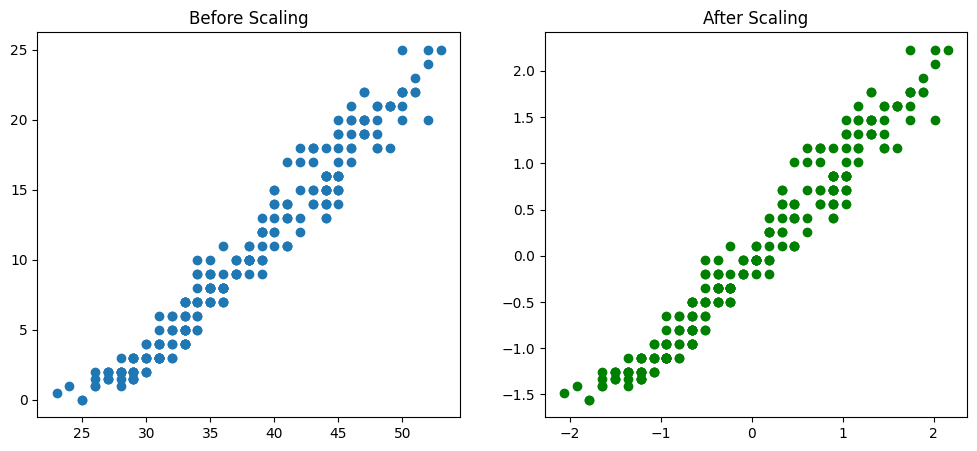

In [28]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(X_train['Age'], X_train['Years of Experience'])
ax1.set_title("Before Scaling")
ax2.scatter(X_train_scaled['Age'], X_train_scaled['Years of Experience'],color='green')
ax2.set_title("After Scaling")
plt.show()


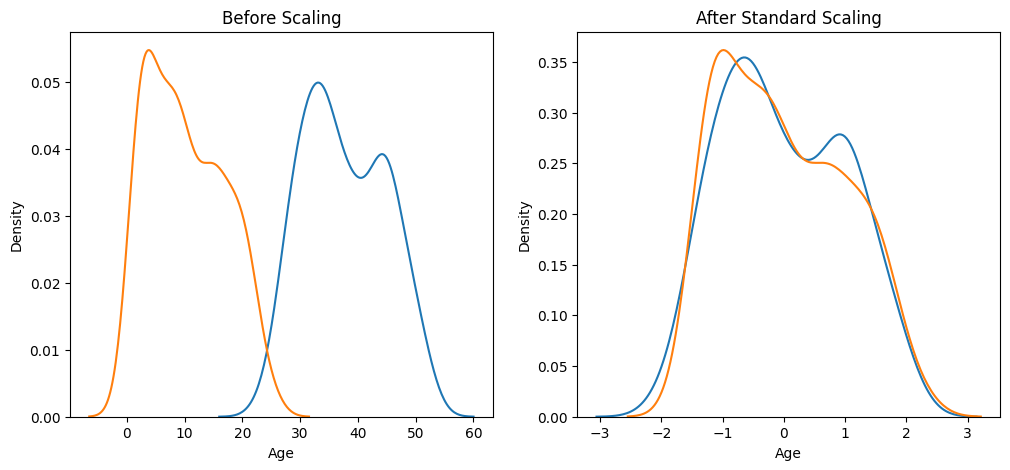

In [ ]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(X_train['Age'], ax=ax1)
sns.kdeplot(X_train['Years of Experience'], ax=ax1)

# after scaling
ax2.set_title('After Standard Scaling')
sns.kdeplot(x=X_train_scaled['Age'], ax=ax2)
sns.kdeplot(x=X_train_scaled['Years of Experience'], ax=ax2)
plt.show()

Comparison of Distributions

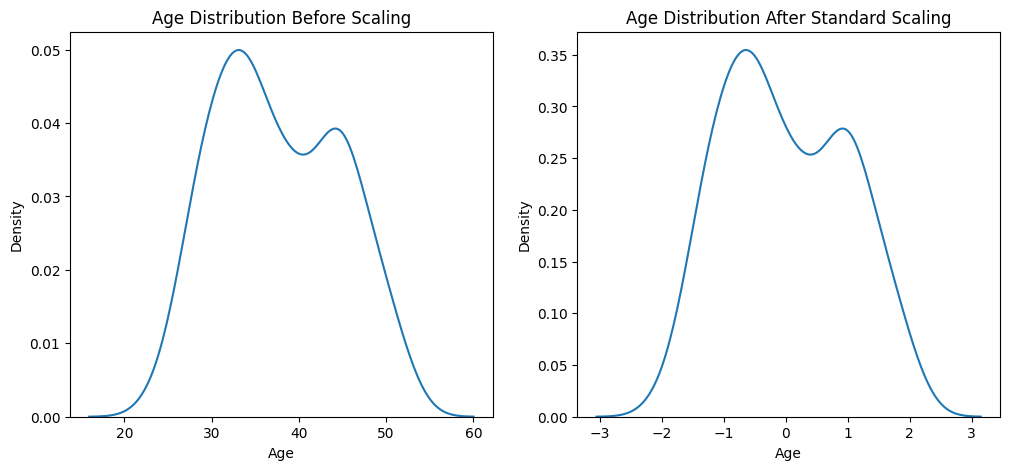

In [ ]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Age Distribution Before Scaling')
sns.kdeplot(X_train['Age'], ax=ax1)

# after scaling
ax2.set_title('Age Distribution After Standard Scaling')
sns.kdeplot(x=X_train_scaled['Age'], ax=ax2)
plt.show()

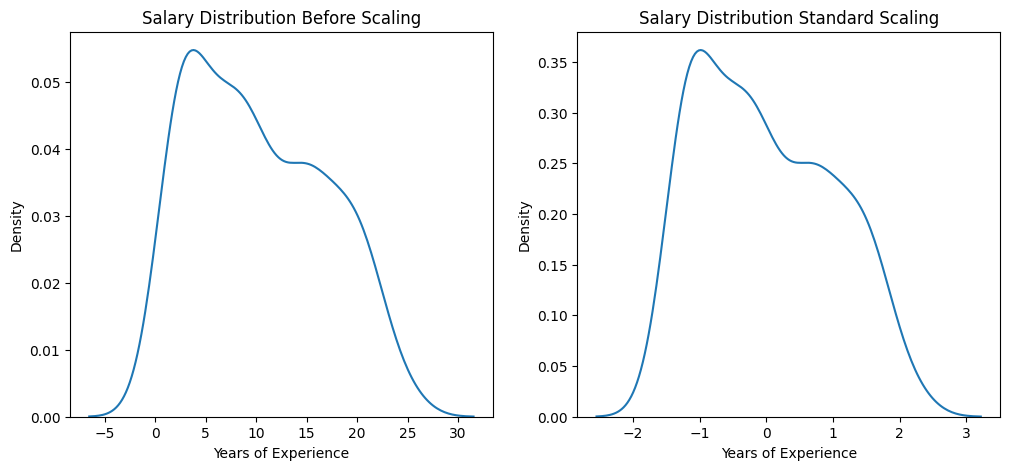

In [ ]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Salary Distribution Before Scaling')
sns.kdeplot(X_train['Years of Experience'], ax=ax1)

# after scaling
ax2.set_title('Salary Distribution Standard Scaling')
sns.kdeplot(x=X_train_scaled['Years of Experience'], ax=ax2)
plt.show()

Why scaling is important?

In [33]:
from sklearn.linear_model import LogisticRegression

In [34]:
lr = LogisticRegression()
lr_scaled = LogisticRegression()

In [38]:
# to delete null values from a column
df1[X_train].dropna()

ValueError: Boolean array expected for the condition, not object

In [37]:
lr.fit(X_train,y_train)
lr_scaled.fit(X_train_scaled,y_train)

ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values